Análise dos Microdados do ENEM – Goiás

Disciplina: CESAR  
Curso:Ciência de Dados / IA  
Instituição: UNISO  

Este notebook apresenta uma análise exploratória dos microdados do ENEM,
com foco nos participantes do estado de Goiás.


# Importação de bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



# Carregamento dos dados

In [3]:
df_go_resultados = df_resultados[df_resultados["SG_UF_PROVA"] == "GO"]
df_go_participantes = df_participantes[df_participantes["SG_UF_PROVA"] == "GO"]

# Visão inicial

Não tratada

In [2]:
import pandas as pd

df_resultados = pd.read_csv(
    "../dados/bruto/RESULTADOS_2024.csv",
    sep=";",
    encoding="latin1",
    low_memory=False
)

df_participantes = pd.read_csv(
    "../dados/bruto/PARTICIPANTES_2024.csv",
    sep=";",
    encoding="latin1",
    low_memory=False
)

df_resultados.shape, df_participantes.shape


((4332944, 42), (4332944, 38))

In [4]:
df_resultados.head()
df_participantes.info()


<class 'pandas.DataFrame'>
RangeIndex: 4332944 entries, 0 to 4332943
Data columns (total 38 columns):
 #   Column              Dtype  
---  ------              -----  
 0   NU_INSCRICAO        int64  
 1   NU_ANO              int64  
 2   TP_FAIXA_ETARIA     int64  
 3   TP_SEXO             str    
 4   TP_ESTADO_CIVIL     int64  
 5   TP_COR_RACA         int64  
 6   TP_NACIONALIDADE    int64  
 7   TP_ST_CONCLUSAO     int64  
 8   TP_ANO_CONCLUIU     int64  
 9   TP_ENSINO           float64
 10  IN_TREINEIRO        int64  
 11  CO_MUNICIPIO_PROVA  int64  
 12  NO_MUNICIPIO_PROVA  str    
 13  CO_UF_PROVA         int64  
 14  SG_UF_PROVA         str    
 15  Q001                str    
 16  Q002                str    
 17  Q003                str    
 18  Q004                str    
 19  Q005                int64  
 20  Q006                str    
 21  Q007                str    
 22  Q008                str    
 23  Q009                str    
 24  Q010                str    
 25  Q0

# Limpeza e Tratamento

In [ ]:
Selecionar apenas colunas necessárias

In [5]:
coluna_notas = [
    "SG_UF_PROVA",
    "NU_NOTA_LC",
    "NU_NOTA_MT",
    "NU_NOTA_CH",
    "NU_NOTA_CN",
    "NU_NOTA_REDACAO",
]

df = df_resultados[coluna_notas].copy()
print ("Base Inicial:", df.shape)

Base Inicial: (4332944, 6)


Colocando nomes legíveis

In [7]:
df = df.rename(columns={
    "NU_NOTA_LC": "Linguagens",
    "NU_NOTA_MT": "Matemática",
    "NU_NOTA_CH": "Ciências Humanas",
    "NU_NOTA_CN": "Ciências da Natureza",
    "NU_NOTA_REDACAO": "Redação"
})

print("Colunas renomeadas:")
print(df.columns)

Colunas renomeadas:
Index(['SG_UF_PROVA', 'Linguagens', 'Matemática', 'Ciências Humanas',
       'Ciências da Natureza', 'Redação'],
      dtype='str')


Remoção de registros duplicados

In [8]:
duplicados = df.duplicated().sum()
print("Quantidade de registros duplicados:", duplicados)
df = df.drop_duplicates ()
print ("Base apóes remover duplicados:", df.shape)

Quantidade de registros duplicados: 1151156
Base apóes remover duplicados: (3181788, 6)


Remoção de ausentes

In [10]:
print("\nValores nulos antes da remoção:")
print(df.isnull().sum())

df = df.dropna(subset=[
    "Linguagens",
    "Matemática",
    "Ciências Humanas",
    "Ciências da Natureza",
    "Redação"
])

print("\nValores nulos após remoção:")
print(df.isnull().sum())

print("Base após remover NaN:", df.shape)


Valores nulos antes da remoção:
SG_UF_PROVA                  0
Linguagens               14842
Matemática              176888
Ciências Humanas         14842
Ciências da Natureza    176888
Redação                  14842
dtype: int64

Valores nulos após remoção:
SG_UF_PROVA             0
Linguagens              0
Matemática              0
Ciências Humanas        0
Ciências da Natureza    0
Redação                 0
dtype: int64
Base após remover NaN: (2990085, 6)


Garantir intervalo das notas (0 a 1000)

In [11]:
colunas_notas_numericas = [
    "Linguagens",
    "Matemática",
    "Ciências Humanas",
    "Ciências da Natureza",
    "Redação",
]

for col in colunas_notas_numericas:
    df = df[(df[col] >= 0) & (df[col] <= 1000)]
print("Base após validar o intervalo das notas:", df.shape)

Base após validar o intervalo das notas: (2990085, 6)


Conferindo limpeza

In [12]:
print("\nResumo estatístico após limpeza:")
print(df.describe())

print("\nLimpeza concluída.")


Resumo estatístico após limpeza:
         Linguagens    Matemática  Ciências Humanas  Ciências da Natureza  \
count  2.990085e+06  2.990085e+06      2.990085e+06          2.990085e+06   
mean   5.266230e+02  5.270825e+02      5.142141e+02          4.940272e+02   
std    6.865276e+01  1.141688e+02      9.155267e+01          7.898593e+01   
min    0.000000e+00  0.000000e+00      0.000000e+00          0.000000e+00   
25%    4.867000e+02  4.313000e+02      4.502000e+02          4.315000e+02   
50%    5.334000e+02  4.992000e+02      5.194000e+02          4.885000e+02   
75%    5.736000e+02  6.110000e+02      5.785000e+02          5.503000e+02   
max    7.958000e+02  9.619000e+02      8.197000e+02          8.672000e+02   

            Redação  
count  2.990085e+06  
mean   6.346677e+02  
std    2.090931e+02  
min    0.000000e+00  
25%    5.200000e+02  
50%    6.400000e+02  
75%    8.000000e+02  
max    1.000000e+03  

Limpeza concluída.


# 3. Análise Comparativa — Goiás vs Brasil

Nesta seção, comparamos o desempenho médio dos participantes do ENEM 2024
do estado de Goiás (GO) com a média nacional (Brasil),
considerando as cinco áreas avaliadas.

Garantindo dados limpos

In [20]:
colunas_notas = [
    "Linguagens",
    "Matemática",
    "Ciências Humanas",
    "Ciências da Natureza",
    "Redação"
]

df_limpo = df.dropna(subset=colunas_notas)

In [18]:
print(df.columns)

Index(['SG_UF_PROVA', 'Linguagens', 'Matemática', 'Ciências Humanas',
       'Ciências da Natureza', 'Redação'],
      dtype='str')


Separar Go do Brasil

In [21]:
df_go = df[df["SG_UF_PROVA"] == "GO"]
df_br = df  # Brasil inteiro

tamanho dos dados

In [22]:
print("Tamanho GO:", df_go.shape)
print("Tamanho Brasil:", df_br.shape)

Tamanho GO: (102473, 6)
Tamanho Brasil: (2990085, 6)


calculo das médias

In [23]:
colunas_notas = [
    "Linguagens",
    "Matemática",
    "Ciências Humanas",
    "Ciências da Natureza",
    "Redação"
]

medias_go = df_go[colunas_notas].mean()
medias_br = df_br[colunas_notas].mean()

df_medias = pd.DataFrame({
    "Média_GO": medias_go,
    "Média_BR": medias_br
})

df_medias["Diferença"] = df_medias["Média_GO"] - df_medias["Média_BR"]
df_medias["Diferença_%"] = (df_medias["Diferença"] / df_medias["Média_BR"]) * 100

df_medias.round(2)

,Média_GO,Média_BR,Diferença,Diferença_%
Linguagens,525.05,526.62,-1.57,-0.30
Matemática,527.51,527.08,0.43,0.08
Ciências Humanas,513.12,514.21,-1.09,-0.21
Ciências da Natureza,494.66,494.03,0.63,0.13
Redação,659.54,634.67,24.87,3.92


Desvio padrão das notas

In [24]:
desvio_go = df_go[colunas_notas].std()
desvio_br = df_br[colunas_notas].std()

df_desvios = pd.DataFrame({
    "Desvio_GO": desvio_go,
    "Desvio_BR": desvio_br
})

df_desvios.round(2)

,Desvio_GO,Desvio_BR
Linguagens,66.60,68.65
Matemática,113.11,114.17
Ciências Humanas,89.76,91.55
Ciências da Natureza,78.85,78.99
Redação,200.86,209.09


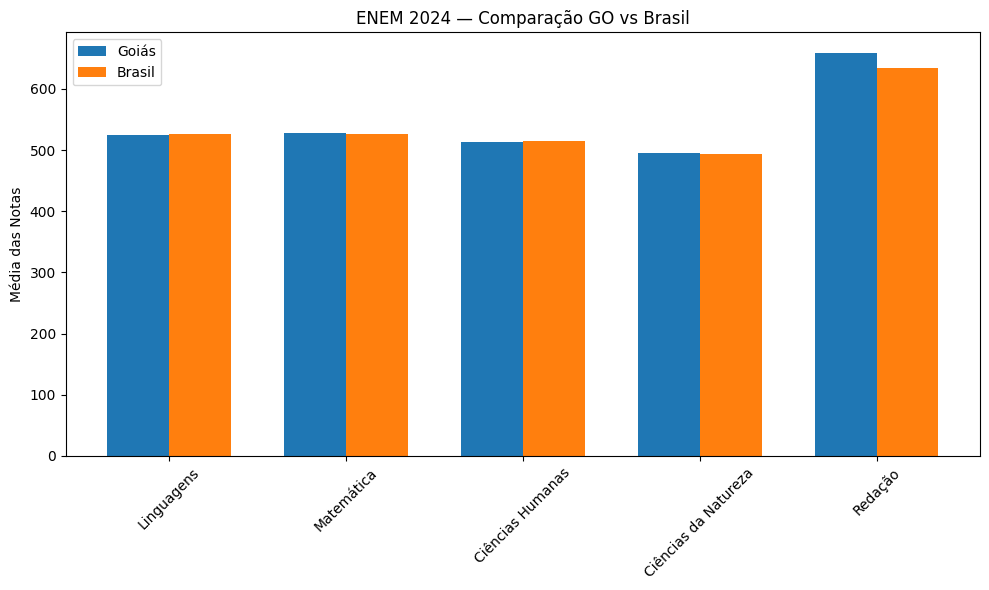

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

disciplinas = df_medias.index
x = np.arange(len(disciplinas))
width = 0.35

fig, ax = plt.subplots(figsize=(10,6))

ax.bar(x - width/2, df_medias["Média_GO"], width, label='Goiás')
ax.bar(x + width/2, df_medias["Média_BR"], width, label='Brasil')

ax.set_ylabel('Média das Notas')
ax.set_title('ENEM 2024 — Comparação GO vs Brasil')
ax.set_xticks(x)
ax.set_xticklabels(disciplinas)
ax.legend()


plt.xticks(rotation=45)
plt.tight_layout()
plt.show()